# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

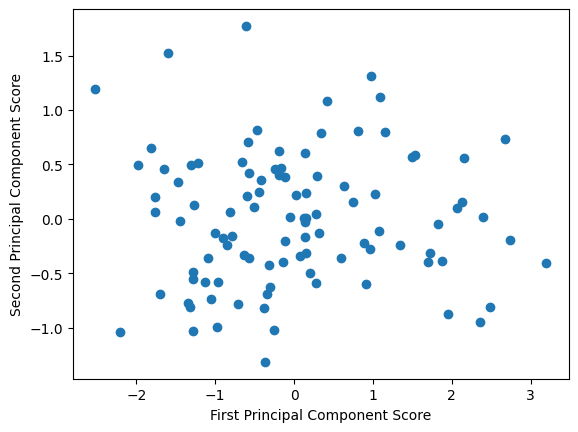

In [215]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

## Info

For these datasets, I will be using logistic regression instead of linear regression due to all of the target variables being binary. I also will be using predict_proba to see the likelihood the model will predict that the user will purchase that specific item.

In [216]:
from sklearn.linear_model import LogisticRegression

## Dataset 1: Instacart Analysis

In [217]:
data1 = pd.read_csv('/workspaces/DX699---HW-Assignments/instacart.csv')

data1.head()

,user_id,product_id,times_purchased,num_orders,frequency,Product Popularity,Last Product Order,Last Order,Orders Since Last Purchase,ordered
0,71,45,5,23,0.217391,0.005895,9,23,14,0.0
1,71,117,19,23,0.826087,0.001220,23,23,0,1.0
2,71,2078,1,23,0.043478,0.006499,3,23,20,0.0
3,71,2825,2,23,0.086957,0.003750,6,23,17,0.0
4,71,3376,2,23,0.086957,0.003609,19,23,4,1.0


In [218]:
transform_cols = ['times_purchased', 'num_orders', 'frequency', 'Product Popularity', 'Last Product Order', 'Last Order', 'Orders Since Last Purchase']

for col in transform_cols:
    data1[f'log_{col}'] = np.log1p(data1[col])

In [219]:
data1_transformed = data1.drop(columns = ['times_purchased', 'num_orders', 'frequency', 'Product Popularity', 'Last Product Order', 'Last Order', 'Orders Since Last Purchase'])

In [220]:
data1_transformed.head()

,user_id,product_id,ordered,log_times_purchased,log_num_orders,log_frequency,log_Product Popularity,log_Last Product Order,log_Last Order,log_Orders Since Last Purchase
0,71,45,0.0,1.791759,3.178054,0.196710,0.005878,2.302585,3.178054,2.708050
1,71,117,1.0,2.995732,3.178054,0.602175,0.001219,3.178054,3.178054,0.000000
2,71,2078,0.0,0.693147,3.178054,0.042560,0.006478,1.386294,3.178054,3.044522
3,71,2825,0.0,1.098612,3.178054,0.083382,0.003743,1.945910,3.178054,2.890372
4,71,3376,1.0,1.098612,3.178054,0.083382,0.003602,2.995732,3.178054,1.609438


Text(0, 0.5, 'Log Last Order')

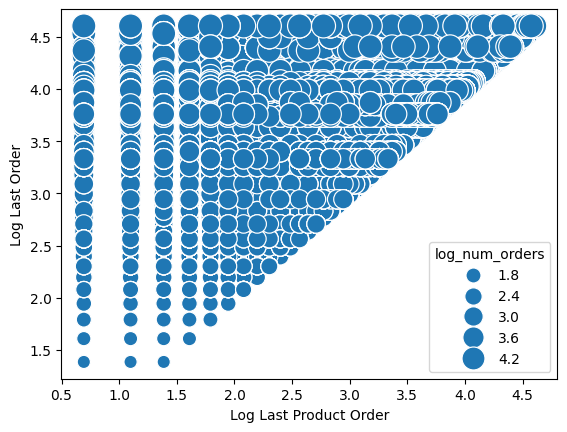

In [254]:
import seaborn as sns

minorders = data1_transformed['log_num_orders'].min()
maxorders = data1_transformed['log_num_orders'].max()
maxbubble = 300
ax = sns.scatterplot(data = data1_transformed, x = "log_Last Product Order", y = "log_Last Order", size = "log_num_orders", sizes = (minorders / maxorders * maxbubble, maxbubble))
ax.set_xlabel("Log Last Product Order")
ax.set_ylabel("Log Last Order")

Looking at the bubble chart, it is clear that as the last product order and last order increase, the number of orders also increases with them. This shows that number of orders is strongly correlated with both of log last product order and log last order.

The next thing I will be looking at is the principal components analysis of the columns in the dataframe.

In [221]:
numeric_columns = data1_transformed.select_dtypes(include = 'number').columns

pca = decomposition.PCA(n_components = 3)
pca.fit(data1_transformed[numeric_columns])
pca.explained_variance_ratio_

array([9.45454337e-01, 5.45456618e-02, 6.75732424e-10])

Looking at the PCA for 3 components, the first component having a PCA explained variance ration of 94.5% does make sense. This is because when I looked at the correlations last week, a lot of the variables shared high correlations. This made sense then due to a lot of the features being created during feature engineering.

The next step is gonna be using logistic regression to predict the likelihood of the model predicting a user ordered the item.

In [250]:
X = data1_transformed.drop(columns = 'ordered')
y = data1_transformed['ordered']

model = LogisticRegression(max_iter = 500)

In [251]:
model.fit(X, y)

probs = model.predict_proba(X)[:, 1]

print(probs[0:11])
print(probs[150000:150011])
print(probs[320000: 320011])

[0.03223736 0.50927941 0.01013363 0.01507512 0.03394499 0.05667576
 0.01027979 0.07699118 0.22009121 0.07695794 0.01684194]
[0.11249099 0.05771098 0.0862223  0.03566857 0.1162996  0.05814653
 0.11330634 0.05409405 0.05083915 0.03578327 0.18188456]
[0.01065225 0.04240696 0.06788066 0.01214306 0.08975262 0.03539562
 0.00584242 0.01006284 0.01313014 0.00572111 0.00610904]


Looking at this, the model does not have very high probabilities of correctly predicting whether an item is ordered or not. I partially believe this is due to the user id and product id being included in the features. I am going to do a second test without those to see if the model performs better. I also made the max iterations higher due to a convergence warning I got when I intially ran the model.

In [252]:
X = data1_transformed.drop(columns = ['user_id', 'product_id', 'ordered'])
y = data1_transformed['ordered']

model = LogisticRegression(max_iter = 500)

In [253]:
model.fit(X, y)

probs = model.predict_proba(X)[:, 1]

print(probs[0:11])
print(probs[150000:150011])
print(probs[320000: 320011])

[0.03018738 0.49670719 0.00860732 0.01370038 0.03582113 0.05702352
 0.00998488 0.07517471 0.20699943 0.07503911 0.01870579]
[0.11229715 0.05547699 0.08183042 0.03457957 0.11110634 0.05611406
 0.11228538 0.05178594 0.05590598 0.03453601 0.20662789]
[0.01337699 0.04675272 0.0699467  0.015065   0.09314728 0.0369422
 0.00616984 0.01255662 0.01621676 0.00528616 0.00452113]


Looking at these probabilities, the model still is not producing high probabilities of predicting the item is purchased. This is concerning and I am curious what can be done to make the model perform better.

## Dataset 2: Amazon Reviews

In [222]:
small_reviews = pd.read_csv('/workspaces/DX699---HW-Assignments/small_reviews[1].csv')
small_reviews.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Excellent! Yummy!,Excellent!! Yummy! Great with other foods and...,[],B00CM36GAQ,B00CM36GAQ,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:41:22.395,0,True
1,5,Delicious!!! Yum!,Excellent! The best! I use it with my beef a...,[],B074J5WVYH,B0759B7KLH,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:40:00.380,0,True
2,5,"Extremely Delicious, but expensive imo",These are very tasty. They are extremely soft ...,[],B079TRNVHX,B079TRNVHX,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:20:24.527,1,True
3,5,Delicious!,My favorite!,[],B07194LN2Z,B07194LN2Z,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-10 05:41:59.614,0,True
4,5,Great taste,Great for making brownies and crinkle cookies.,[],B005CD4196,B005CD4196,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-10 05:41:34.965,7,True


In [223]:
small_meta = pd.read_csv('/workspaces/DX699---HW-Assignments/small_meta[1].csv')
small_meta.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,Grocery,Dark Roast Pure Coffee,4.7,9,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'YouCut_20220Cafe Du Monde Coffee C...,Luzianne,"['Grocery & Gourmet Food', 'Beverages', 'Coffee']","{'Brand': 'Luzianne', 'Item Form': 'Ground', '...",B00NE08WM6,NaN,NaN,NaN
1,Grocery,PICARAS Galletas Peruanas Bañadas en Chocolate...,4.5,12,['2 Bags of PICARAS Galletas Bañadas en Chocol...,['2 Bags of PICARAS Galletas Bañadas en Chocol...,15.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],Winters,"['Grocery & Gourmet Food', 'Breads & Bakery', ...","{'Flavor': 'chocolate', 'Unit Count': '12.00 C...",B084Q13Q5Q,NaN,NaN,NaN
2,Grocery,Chipped Beef and Gravy By Patterson's - Great ...,3.2,5,['Six (6) 8-ounce cans of delicious chipped be...,"[""Delicious corned beef gravy is ready when yo...",NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Pattersons,"['Grocery & Gourmet Food', 'Pantry Staples', '...",{'Package Dimensions': '8.4 x 5.8 x 3.4 inches...,B00KBRUYVM,NaN,NaN,NaN
3,Grocery,Asher's Sugar Free Milk Chocolate Cordial Cher...,5.0,6,[],[],29.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'No Sugar Added Chocolate Truffles'...,Generic,"['Grocery & Gourmet Food', 'Snacks & Sweets', ...","{'Brand': 'Generic', 'Item Form': 'Ball', 'Cho...",B0BN4PW255,NaN,NaN,NaN
4,Grocery,Messmer Peppermint 25 bags (6er pack),3.5,5,[],[],29.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],Messmer,[],"{'Brand': 'Messmer', 'Item Form': 'Teabags', '...",B06X9DC27H,NaN,NaN,NaN


In [224]:
small_meta = small_meta.set_index(keys = 'parent_asin')

small_meta = small_meta.drop(columns = ['title', 'images'])

data2 = small_reviews.join(small_meta, on = 'parent_asin', how = 'inner')

data2.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,...,features,description,price,videos,store,categories,details,bought_together,subtitle,author
10,5,Yummy tea!,Luckily I purchased this on a lightning deal f...,[],B00VFYPK82,B01KCG2OP0,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2019-01-23 01:51:58.951,0,False,...,['HIMALAYAS\u200b GOLDEN\u200b GIFT TO THE WOR...,[],24.99,"[{'title': ""Taste Test: Vahdam India's Origina...",VAHDAM,"['Grocery & Gourmet Food', 'Beverages', 'Tea',...","{'Brand': 'VAHDAM', 'Item Form': 'Loose Leaf',...",NaN,NaN,NaN
22,1,Overpriced With No Noticeable Difference,I have tried four other reishi products on the...,[],B00MMHV878,B0BCZDNTXD,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,2015-12-18 16:30:52.000,26,True,...,['BE WELL — Mushroom Elixir with Chaga contain...,['Drink to your daily well-being with our Chag...,27.54,"[{'title': ""Lion's Mane Elixir Review"", 'url':...",Four Sigmatic,"['Grocery & Gourmet Food', 'Beverages', 'Tea',...","{'Item Form': 'Powder', 'Brand': 'Four Sigmati...",NaN,NaN,NaN
38,4,Four Stars,Love it but it could be a little more robust. ...,[],B0030IQ71A,B07MDTNZ66,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2018-02-22 16:33:14.462,0,True,...,['Pure Tanzania AA Coffee from the Nglia Estat...,[],NaN,[{'title': 'Volcanica Coffee - Specialty Coffe...,Volcanica Coffee,"['Grocery & Gourmet Food', 'Beverages', 'Coffe...","{'Is Discontinued By Manufacturer': 'No', 'Pro...",NaN,NaN,NaN
40,5,More Please!,The best tasting Nutritional Yeast on the plan...,[],B00PJ3IPMI,B0B97CPJ67,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2017-09-09 23:16:57.759,0,True,...,['FLAVOR-PACKED NUTRITIONAL YEAST: Our Nutriti...,[],14.99,"[{'title': ""You'll love this Nutritional Yeast...",Sari Foods Co,"['Grocery & Gourmet Food', 'Pantry Staples', '...","{'Brand': 'Sari Foods Co', 'Item Form': 'Powde...",NaN,NaN,NaN
83,5,Great flavors,Reasonable price and great quality!,[],B079V8CKDM,B0B9C9DQYR,AFDERBL3G23J5U6HHQBAZLTREKOA,2023-01-07 18:25:12.338,0,True,...,"['100 Donut Style Blend coffee pods', 'Blend o...",['Solimo Donut Style Blend coffee k-cup pods a...,28.82,[{'title': 'What you need to know about Solimo...,Solimo,"['Grocery & Gourmet Food', 'Beverages', 'Coffe...",{'Product Dimensions': '11.75 x 9.87 x 7.25 in...,NaN,NaN,NaN


In [225]:
data2 = data2.drop(columns = ['main_category', 'store', 'rating_number', 'videos', 'images', 'subtitle', 'author', 'bought_together', 'features', 'description', 'details', 'timestamp', 'text', 'title'])

In [226]:
data2.head()

,rating,asin,parent_asin,user_id,helpful_vote,verified_purchase,average_rating,price,categories
10,5,B00VFYPK82,B01KCG2OP0,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,0,False,4.5,24.99,"['Grocery & Gourmet Food', 'Beverages', 'Tea',..."
22,1,B00MMHV878,B0BCZDNTXD,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,26,True,4.4,27.54,"['Grocery & Gourmet Food', 'Beverages', 'Tea',..."
38,4,B0030IQ71A,B07MDTNZ66,AGKHLEW2SOWHNMFQIJGBECAF7INQ,0,True,4.4,NaN,"['Grocery & Gourmet Food', 'Beverages', 'Coffe..."
40,5,B00PJ3IPMI,B0B97CPJ67,AGKHLEW2SOWHNMFQIJGBECAF7INQ,0,True,4.6,14.99,"['Grocery & Gourmet Food', 'Pantry Staples', '..."
83,5,B079V8CKDM,B0B9C9DQYR,AFDERBL3G23J5U6HHQBAZLTREKOA,0,True,4.4,28.82,"['Grocery & Gourmet Food', 'Beverages', 'Coffe..."


In [227]:
data2['product_review_count'] = data2.groupby('asin').transform('size')
data2['user_review_count'] = data2.groupby('user_id').transform('size')

data2.head()

,rating,asin,parent_asin,user_id,helpful_vote,verified_purchase,average_rating,price,categories,product_review_count,user_review_count
10,5,B00VFYPK82,B01KCG2OP0,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,0,False,4.5,24.99,"['Grocery & Gourmet Food', 'Beverages', 'Tea',...",1,1
22,1,B00MMHV878,B0BCZDNTXD,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,26,True,4.4,27.54,"['Grocery & Gourmet Food', 'Beverages', 'Tea',...",1,1
38,4,B0030IQ71A,B07MDTNZ66,AGKHLEW2SOWHNMFQIJGBECAF7INQ,0,True,4.4,NaN,"['Grocery & Gourmet Food', 'Beverages', 'Coffe...",1,2
40,5,B00PJ3IPMI,B0B97CPJ67,AGKHLEW2SOWHNMFQIJGBECAF7INQ,0,True,4.6,14.99,"['Grocery & Gourmet Food', 'Pantry Staples', '...",1,2
83,5,B079V8CKDM,B0B9C9DQYR,AFDERBL3G23J5U6HHQBAZLTREKOA,0,True,4.4,28.82,"['Grocery & Gourmet Food', 'Beverages', 'Coffe...",4,1


In [228]:
data2['price'] = data2['price'].fillna(data2['price'].median())

data2['price'].isna().sum()

np.int64(0)

In [229]:
import ast

data2['categories'] = data2['categories'].apply(ast.literal_eval)

data2['categories'].head()

10      [Grocery & Gourmet Food, Beverages, Tea, Black]
22    [Grocery & Gourmet Food, Beverages, Tea, Fruit...
38    [Grocery & Gourmet Food, Beverages, Coffee, Wh...
40    [Grocery & Gourmet Food, Pantry Staples, Cooki...
83    [Grocery & Gourmet Food, Beverages, Coffee, Si...
Name: categories, dtype: object

In [230]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

categories = pd.DataFrame(mlb.fit_transform(data2['categories']), columns = mlb.classes_, index = data2.index)

categories

,Active Dry Yeasts,Almond Butter,Almonds,Apple Cider,Assortments & Samplers,Bakery & Dessert Gifts,"Baking Chocolates, Carob & Cocoa",Baking Mixes,"Baking Syrups, Sugars & Sweeteners",Barbecue,...,Vegetables,Vinegars,Wafers,Walnuts,Water,Water Flavoring Drops,Wheat,White,Whole Coffee Beans,Yellow Mustard
10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
22,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
38,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
40,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
83,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9876,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9903,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
9935,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9941,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [231]:
top_30 = categories.sum().sort_values(ascending = False).head(31).index

categories = categories[top_30[1:31]]

categories

,Beverages,Snacks & Sweets,Pantry Staples,Coffee,Snack Foods,Candy & Chocolate,"Bottled Beverages, Water & Drink Mixes",Cooking & Baking,Breads & Bakery,Single-Serve Capsules & Pods,...,Granola,Fruit & Herbal Tea,Herbal,Bars,Roasted Coffee Beans,Whole Coffee Beans,"Canned, Jarred & Packaged Foods",Cold Cereals,"Baking Syrups, Sugars & Sweeteners",Black
10,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
22,1,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
38,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
40,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
83,1,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9876,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9903,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
9935,1,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
9941,1,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [232]:
data2 = data2.drop(columns = 'categories')

data2 = data2.join(categories)

data2.head()

,rating,asin,parent_asin,user_id,helpful_vote,verified_purchase,average_rating,price,product_review_count,user_review_count,...,Granola,Fruit & Herbal Tea,Herbal,Bars,Roasted Coffee Beans,Whole Coffee Beans,"Canned, Jarred & Packaged Foods",Cold Cereals,"Baking Syrups, Sugars & Sweeteners",Black
10,5,B00VFYPK82,B01KCG2OP0,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,0,False,4.5,24.99,1,1,...,0,0,0,0,0,0,0,0,0,1
22,1,B00MMHV878,B0BCZDNTXD,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,26,True,4.4,27.54,1,1,...,0,1,1,0,0,0,0,0,0,0
38,4,B0030IQ71A,B07MDTNZ66,AGKHLEW2SOWHNMFQIJGBECAF7INQ,0,True,4.4,16.99,1,2,...,0,0,0,0,1,1,0,0,0,0
40,5,B00PJ3IPMI,B0B97CPJ67,AGKHLEW2SOWHNMFQIJGBECAF7INQ,0,True,4.6,14.99,1,2,...,0,0,0,0,0,0,0,0,0,0
83,5,B079V8CKDM,B0B9C9DQYR,AFDERBL3G23J5U6HHQBAZLTREKOA,0,True,4.4,28.82,4,1,...,0,0,0,0,0,0,0,0,0,0


In [233]:
columns_to_transform = ['helpful_vote', 'average_rating', 'price', 'product_review_count', 'user_review_count']

for col in columns_to_transform:
    data2[f'log_{col}'] = np.log1p(data2[col])

data2_transformed = data2.drop(columns = ['helpful_vote', 'average_rating', 'price', 'product_review_count', 'user_review_count'])

In [234]:
data2_transformed = data2_transformed.reset_index(drop = True)

data2_transformed.head()

,rating,asin,parent_asin,user_id,verified_purchase,Beverages,Snacks & Sweets,Pantry Staples,Coffee,Snack Foods,...,Whole Coffee Beans,"Canned, Jarred & Packaged Foods",Cold Cereals,"Baking Syrups, Sugars & Sweeteners",Black,log_helpful_vote,log_average_rating,log_price,log_product_review_count,log_user_review_count
0,5,B00VFYPK82,B01KCG2OP0,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,False,1,0,0,0,0,...,0,0,0,0,1,0.000000,1.704748,3.257712,0.693147,0.693147
1,1,B00MMHV878,B0BCZDNTXD,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,True,1,0,0,0,0,...,0,0,0,0,0,3.295837,1.686399,3.351307,0.693147,0.693147
2,4,B0030IQ71A,B07MDTNZ66,AGKHLEW2SOWHNMFQIJGBECAF7INQ,True,1,0,0,1,0,...,1,0,0,0,0,0.000000,1.686399,2.889816,0.693147,1.098612
3,5,B00PJ3IPMI,B0B97CPJ67,AGKHLEW2SOWHNMFQIJGBECAF7INQ,True,0,0,1,0,0,...,0,0,0,0,0,0.000000,1.722767,2.771964,0.693147,1.098612
4,5,B079V8CKDM,B0B9C9DQYR,AFDERBL3G23J5U6HHQBAZLTREKOA,True,1,0,0,1,0,...,0,0,0,0,0,0.000000,1.686399,3.395179,1.609438,0.693147


In [235]:
for i in range(len(data2_transformed)):
    if data2_transformed.iloc[i]['rating'] == 4:
        data2_transformed.loc[i, 'liked'] = 1
    elif data2_transformed.iloc[i]['rating'] == 5:
        data2_transformed.loc[i, 'liked'] = 1
    else:
        data2_transformed.loc[i, 'liked'] = 0

In [236]:
data2_transformed.head()

,rating,asin,parent_asin,user_id,verified_purchase,Beverages,Snacks & Sweets,Pantry Staples,Coffee,Snack Foods,...,"Canned, Jarred & Packaged Foods",Cold Cereals,"Baking Syrups, Sugars & Sweeteners",Black,log_helpful_vote,log_average_rating,log_price,log_product_review_count,log_user_review_count,liked
0,5,B00VFYPK82,B01KCG2OP0,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,False,1,0,0,0,0,...,0,0,0,1,0.000000,1.704748,3.257712,0.693147,0.693147,1.0
1,1,B00MMHV878,B0BCZDNTXD,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,True,1,0,0,0,0,...,0,0,0,0,3.295837,1.686399,3.351307,0.693147,0.693147,0.0
2,4,B0030IQ71A,B07MDTNZ66,AGKHLEW2SOWHNMFQIJGBECAF7INQ,True,1,0,0,1,0,...,0,0,0,0,0.000000,1.686399,2.889816,0.693147,1.098612,1.0
3,5,B00PJ3IPMI,B0B97CPJ67,AGKHLEW2SOWHNMFQIJGBECAF7INQ,True,0,0,1,0,0,...,0,0,0,0,0.000000,1.722767,2.771964,0.693147,1.098612,1.0
4,5,B079V8CKDM,B0B9C9DQYR,AFDERBL3G23J5U6HHQBAZLTREKOA,True,1,0,0,1,0,...,0,0,0,0,0.000000,1.686399,3.395179,1.609438,0.693147,1.0


In [239]:
numeric_columns = data2_transformed.select_dtypes(include = 'number').columns

pca = decomposition.PCA(n_components = 3)
pca.fit(data2_transformed[numeric_columns])
pca.explained_variance_ratio_

array([0.25933706, 0.21788816, 0.09418063])

Looking at the PCA, seeing that the first three components have lower scores means that the variance of the data isn't only distributed on one dimension alone like the other datasets. Instead, the variance can be explained by multiple dimensions in the dataset. This also makes sense since a lot of the data is not highly correlated, which can be seen in the heatmap from week 6.

The next step I will be completing is the logistic regression to see the likelihood the model will predict the user will like the item. I will be dropping the string columns for this so the model can be properly fitted.

In [241]:
X = data2_transformed.drop(columns = ['asin', 'parent_asin', 'user_id', 'liked'])
y = data2_transformed['liked']

model = LogisticRegression()

In [243]:
model.fit(X, y)

probs = model.predict_proba(X)[:, 1]

print(probs[0:11])
print(probs[250:261])
print(probs[572:582])

[9.98978001e-01 1.72181943e-05 9.35472393e-01 9.99043215e-01
 9.99426619e-01 9.99339791e-01 9.81080734e-02 9.99218341e-01
 4.63269682e-05 9.98924555e-01 1.91972711e-05]
[0.9991458  0.93100724 0.9392848  0.99916667 0.99928    0.94071719
 0.9991812  0.9994713  0.99933259 0.99945927 0.94260853]
[0.15412756 0.99945451 0.99945446 0.9454198  0.99889583 0.9993181
 0.99921517 0.99879395 0.9994454  0.9994569 ]


Looking at the probabilities, the model did a pretty good job at predicting whether or not an item will be liked. For example, looking at the first two values which were 1 and then 0, it has a 99% chance of correctly predicting the item is liked and then has a very low probability of saying the item that isn't liked would be liked.

## Dataset 3: Ecommerce Data

In [ ]:
data3 = pd.read_csv('/workspaces/DX699---HW-Assignments/data.csv', encoding = 'windows-1252')
data3['Purchased'] = 1
data3.head()

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Purchased
0,1/1/2020,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568,1
1,1/1/2020,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606,1
2,1/1/2020,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280,1
3,1/1/2020,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580,1
4,1/1/2020,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815,1


As stated in my milestone 3 paper, I researched how to create fake purchase rows so I have a true purchased column where there are 0s and 1s. To do this, I found the faker generator but was struggling to find guides on how to use it with Dataframe columns. I asked ChatGPT for help on how to use it on a dataframe and it showed me how to use np.random instead. The chatlog is attached below:
https://chatgpt.com/share/69cd15d1-761c-832b-b2e7-bd3b9da9c925

In [ ]:
customer_id = data3['Customer ID'].values
segments = data3['Segment'].values
cities = data3['City'].values
state = data3['State'].values
region = data3['Region'].values
product_id = data3['Product ID'].values
categories = data3['Category'].values
subcategories = data3['Sub-Category'].values

In [ ]:
def generate_row(df):
    row = {}

    row['Customer ID'] = np.random.choice(customer_id)
    cust_id = row['Customer ID']
    purchased = set(df[df['Customer ID'] == cust_id]['Product ID'])
    candidates = list(set(product_id) - purchased)

    row['Segment'] = np.random.choice(segments)
    row['State'] = np.random.choice(state)
    row['City'] = np.random.choice(cities)
    row['Region'] = np.random.choice(region)
    row['Product ID'] = np.random.choice(candidates)
    row['Category'] = np.random.choice(categories)
    row['Sub-Category'] = np.random.choice(subcategories)

    row['Sales'] = 0
    row['Discount'] = 0
    row['Quantity'] = 0
    row['Profit'] = 0
    row['Purchased'] = 0

    return row

In [ ]:
fake_rows = pd.DataFrame([generate_row(data3) for n in range(1000)])

fake_df = pd.concat([data3, fake_rows], ignore_index = True)

In [ ]:
fake_df = fake_df.drop(columns = ['Row ID', 'Product Name', 'Country', 'Postal Code', 'Order ID', 'Order Date'])

fake_df_encoded = pd.get_dummies(fake_df, columns = ['Ship Mode', 'Segment', 'State', 'Region', 'Category', 'Sub-Category'], dtype = int)

fake_df_encoded.head()

,Customer ID,City,Product ID,Sales,Quantity,Discount,Profit,Purchased,Ship Mode_First Class,Ship Mode_Same Day,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
0,GA-14725,Lorain,FUR-FU-10003878,48.896,4,0.2,8.5568,1,0,0,...,0,0,1,0,0,0,0,0,0,0
1,SC-20725,Los Angeles,FUR-FU-10001215,474.430,11,0.0,199.2606,1,0,0,...,0,0,1,0,0,0,0,0,0,0
2,DP-13390,Franklin,OFF-BI-10002012,3.600,2,0.0,1.7280,1,1,0,...,0,0,0,0,0,0,0,0,0,0
3,JM-15250,Huntsville,OFF-ST-10002743,454.560,5,0.2,-107.9580,1,0,0,...,0,0,0,0,0,0,0,1,0,0
4,JM-15250,Huntsville,FUR-FU-10002116,141.420,5,0.6,-187.3815,1,0,0,...,0,0,1,0,0,0,0,0,0,0


In [ ]:
numeric_columns = fake_df_encoded.select_dtypes(include = 'number').columns

pca = decomposition.PCA(n_components = 3)
pca.fit(fake_df_encoded[numeric_columns])
pca.explained_variance_ratio_

array([9.03264185e-01, 9.67032469e-02, 1.88234844e-05])

Above, I looked at the explained ratio for the first 3 principal components of the dataset. After printing this out, you can se that the first 90% of variance in the data is explained by the first component. This could be due to the overlap in the encoded binary columns, which were also the most correlated columns I saw in my bi-variate analysis during week 6.

I am now going to use logistic regression to predict the probabilities of purchase based off the features. I also am going to drop all of the string columns for my X features as the model can't process them when I fit them to the model.

In [ ]:
model = LogisticRegression()

X = fake_df_encoded.drop(columns = ['Customer ID', 'Product ID', 'City', 'Purchased'])
y = fake_df_encoded['Purchased']

model.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
probs = model.predict_proba(X)[:, 1]
print(probs[0:10])
print(probs[2500 : 2511])
print(probs[4301:4311])

[1.         1.         0.99997303 1.         1.         1.
 1.         1.         1.         1.        ]
[1.         1.         1.         0.99641232 1.         1.
 1.         1.         1.         1.         1.        ]
[0.0017553  0.00114081 0.00130669 0.0013934  0.00188862 0.00131504
 0.00251187 0.00212499 0.0012797  0.00228989]


Looking at the probability predictions, we can see that for the items that have been purchased by users, they have a 99% - 100% probability that the model would predict that user purchased that item. Furthrmore, for the fake rows I added above, there is a 0-0.25% chance the model would predict the user purchased that item. I will say, having all the numerical columns equal to 0 definitely help the model predict whether someone purchases the item or not since how can someone purchase something when quantity equals 0.

## Conclusions

Overall, I did learn a lot about how the variance is explained by the data for each dataset as well as how they do at predicting the probabilities. For datasets 2 and 3, they both performed well, but the first dataset did not. This could be due to the other 2 having a lot of binary encoded columns which that dataset does not. Furthermore, other models could work better for the first dataset when it comes to predicting whether or not an item will be ordered. 

Furthermore, I did not make any bubble charts for datasets 2 and 3 as the columns that are the most correlated are binary which means that they will not properly display the potential correlations between the three columns.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

In [ ]:
import matplotlib.pyplot as plt

data = pd.DataFrame({'Group' : ['US Population', 'Our Customers'], 'Segment 1' : [16, 9], 'Segment 2' : [7,10],
                     'Segment 3': [10, 15], 'Segment 4' : [10, 18], 'Segment 5' : [10, 17], 'Segment 6' : [32, 20],
                     'Segment 7' : [15, 11]})

data.head()

,Group,Segment 1,Segment 2,Segment 3,Segment 4,Segment 5,Segment 6,Segment 7
0,US Population,16,7,10,10,10,32,15
1,Our Customers,9,10,15,18,17,20,11


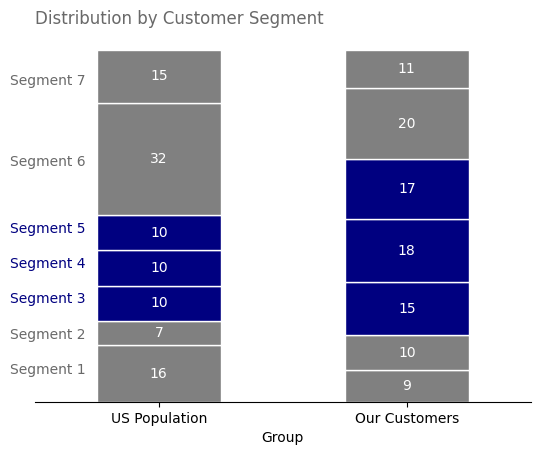

In [ ]:
ax = data.plot(x = 'Group', kind = 'bar', stacked = True, color = ['gray', 'gray', 'navy', 'navy', 'navy', 'gray', 'gray'], edgecolor = 'white', legend = False)

for cont in ax.containers: 
    ax.bar_label(cont, label_type = 'center', color = 'white')

plt.xticks(rotation = 0)
ax.yaxis.set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('Distribution by Customer Segment', loc = 'left', color = 'dimgray')
plt.text(-0.6, 8, 'Segment 1', color = 'dimgray')
plt.text(-0.6, 18, 'Segment 2', color = 'dimgray')
plt.text(-0.6, 28, 'Segment 3', color = 'navy')
plt.text(-0.6, 38, 'Segment 4', color = 'navy')
plt.text(-0.6, 48, 'Segment 5', color = 'navy')
plt.text(-0.6, 67, 'Segment 6', color = 'dimgray')
plt.text(-0.6, 90, 'Segment 7', color = 'dimgray')
plt.show()

This discussion forum was used to help label the segments: https://stackoverflow.com/questions/41296313/stacked-bar-chart-with-centered-labels